<a href="https://colab.research.google.com/github/Jinatsultana/Fall_detection_model_V1/blob/main/Fall_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving sisfall_dataset.zip to sisfall_dataset.zip


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sisfall_dataset.zip', 'sample_data']


In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('/content/sisfall_dataset.zip', 'r')

zip_ref.extractall('/content/dataset')

zip_ref.close()

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [ ]:
import os

print(os.listdir('/content/dataset'))

['SisFall_dataset']


In [ ]:
import os

print(os.listdir('/content/dataset/SisFall_dataset'))

['SA18', 'SA19', 'SA06', 'SE03', 'SA14', 'SA10', 'SA05', 'SA12', 'SA21', 'SE01', 'SA03', 'SE04', 'SE10', 'SA20', 'SE11', 'SA13', 'SA17', 'SA22', 'SE05', 'Supplementary.pdf', 'SE09', 'Readme.txt', 'SE07', 'SE13', 'SA07', 'SA02', 'SA04', 'SE14', 'SA09', 'SA23', 'SA08', 'SE06', 'SA01', 'SA15', 'SE12', 'SA16', 'SE15', 'SA11', 'SE02', 'SE08']


In [ ]:
import os

base_path = '/content/dataset/SisFall_dataset'

# Example folder
sample_folder = os.path.join(base_path, 'SA01')

print(os.listdir(sample_folder)[:10])

['F04_SA01_R02.txt', 'D18_SA01_R05.txt', 'D15_SA01_R03.txt', 'D18_SA01_R04.txt', 'F04_SA01_R04.txt', 'D08_SA01_R04.txt', 'D12_SA01_R04.txt', 'F06_SA01_R05.txt', 'D06_SA01_R05.txt', 'F05_SA01_R04.txt']


In [ ]:
import pandas as pd

file_path = '/content/dataset/SisFall_dataset/SA01/D07_SA01_R04.txt'

data = pd.read_csv(
    file_path,
    header=None,
    delimiter=','
)

print(data.head())

print(data.shape)

   0    1   2   3   4  5   6     7      8
0  2 -260 -11 -42  17 -4   5 -1015    75;
1  2 -258 -12 -40  17 -5  11 -1013    75;
2  4 -262 -10 -40  16 -6   8 -1018    72;
3  0 -261 -13 -39  15 -4   6 -1013    74;
4  0 -259 -11 -39  16 -5   9 -1012    74;
(2400, 9)


In [ ]:
# Last column clean
data[8] = data[8].astype(str).str.replace(';', '')

# Convert all columns to numeric
data = data.astype(float)

print(data.head())

     0      1     2     3     4    5     6       7     8
0  2.0 -260.0 -11.0 -42.0  17.0 -4.0   5.0 -1015.0  75.0
1  2.0 -258.0 -12.0 -40.0  17.0 -5.0  11.0 -1013.0  75.0
2  4.0 -262.0 -10.0 -40.0  16.0 -6.0   8.0 -1018.0  72.0
3  0.0 -261.0 -13.0 -39.0  15.0 -4.0   6.0 -1013.0  74.0
4  0.0 -259.0 -11.0 -39.0  16.0 -5.0   9.0 -1012.0  74.0


In [ ]:
print(data.isnull().sum())

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[-0.40731675 -0.43589725  0.32214743  0.0101544   0.03844565  0.04078883
  -0.496485   -0.58729631  0.31507548]
 [-0.40731675 -0.23182948  0.30370035  0.01661874  0.03844565  0.00312312
  -0.24128657 -0.53765777  0.31507548]
 [-0.08140903 -0.63996501  0.3405945   0.01661874  0.02169981 -0.0345426
  -0.36888578 -0.66175412  0.30121077]
 [-0.73322447 -0.53793113  0.28525328  0.01985091  0.00495398  0.04078883
  -0.45395193 -0.53765777  0.31045391]
 [-0.73322447 -0.33386337  0.32214743  0.01985091  0.02169981  0.00312312
  -0.32635271 -0.5128385   0.31045391]]


In [ ]:
import torch

tensor_data = torch.tensor(
    scaled_data,
    dtype=torch.float32
)

print(tensor_data.shape)

torch.Size([2400, 9])


In [ ]:
window_size = 100

sequences = []

for i in range(len(tensor_data) - window_size):

    seq = tensor_data[i:i+window_size]

    sequences.append(seq)

sequences = torch.stack(sequences)

print(sequences.shape)

torch.Size([2300, 100, 9])


In [ ]:
labels = torch.zeros(
    len(sequences),
    dtype=torch.long
)

print(labels.shape)

torch.Size([2300])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(
    sequences,
    labels
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("DataLoader Ready")

DataLoader Ready


In [ ]:
import torch.nn as nn

class CNNTransformer(nn.Module):

    def __init__(self):

        super(CNNTransformer, self).__init__()

        # CNN Layer
        self.cnn = nn.Conv1d(
            in_channels=9,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=8
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        # Final Classification Layer
        self.fc = nn.Linear(64, 2)

    def forward(self, x):

        # Input Shape:
        # [batch, sequence_length, features]

        x = x.permute(0, 2, 1)

        x = self.cnn(x)

        x = x.permute(2, 0, 1)

        x = self.transformer(x)

        x = x.mean(dim=0)

        x = self.fc(x)

        return x

In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNNTransformer().to(device)

print(model)

/tmp/ipykernel_612/1794981013.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(


CNNTransformer(
  (cnn): Conv1d(9, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer Ready")

Optimizer Ready


In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for x_batch, y_batch in loader:

        # GPU me bhejo
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Previous gradient clear
        optimizer.zero_grad()

        # Forward pass
        outputs = model(x_batch)

        # Loss calculate
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()

        # Weight update
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 1.3059
Epoch 2, Loss: 0.0444
Epoch 3, Loss: 0.0245
Epoch 4, Loss: 0.0152
Epoch 5, Loss: 0.0102


In [ ]:
torch.save(model.state_dict(), "cnn_transformer_model.pth")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from google.colab import files

files.download("cnn_transformer_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for x_batch, y_batch in loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)

        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)

        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 100.00%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for x_batch, y_batch in loader:

        # GPU me bhejo
        x_batch = x_batch.to(device)

        # Prediction
        outputs = model(x_batch)

        # Highest probability class
        _, predicted = torch.max(outputs, 1)

        # Store actual labels
        y_true.extend(y_batch.cpu().numpy())

        # Store predicted labels
        y_pred.extend(predicted.cpu().numpy())

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [ ]:
import torch
import torch.nn as nn

class CNNTransformer(nn.Module):

    def __init__(self):

        super(CNNTransformer, self).__init__()

        self.cnn = nn.Conv1d(
            in_channels=9,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=8
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.fc = nn.Linear(64, 2)

    def forward(self, x):

        x = x.permute(0, 2, 1)

        x = self.cnn(x)

        x = x.permute(2, 0, 1)

        x = self.transformer(x)

        x = x.mean(dim=0)

        x = self.fc(x)

        return x

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNNTransformer().to(device)

print("Model Initialized Successfully")

Model Initialized Successfully


/tmp/ipykernel_612/3646140235.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(


In [ ]:
model.load_state_dict(
    torch.load("cnn_transformer_model.pth")
)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
import os

print(os.listdir('/content'))

['.config', 'sisfall_dataset.zip', 'dataset', 'cnn_transformer_model.pth', 'sample_data']


In [ ]:
from graphviz import Digraph

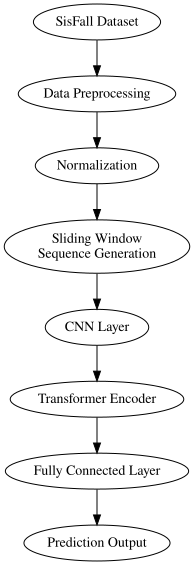

In [ ]:
from graphviz import Digraph

dot = Digraph()

# Nodes
dot.node('A', 'SisFall Dataset')
dot.node('B', 'Data Preprocessing')
dot.node('C', 'Normalization')
dot.node('D', 'Sliding Window\nSequence Generation')
dot.node('E', 'CNN Layer')
dot.node('F', 'Transformer Encoder')
dot.node('G', 'Fully Connected Layer')
dot.node('H', 'Prediction Output')

# Connections
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'H')

# Display Diagram
dot

In [ ]:
import pandas as pd

In [ ]:
comparison_table = pd.DataFrame({

    'Model': [
        'CNN',
        'LSTM',
        'Transformer',
        'Hybrid CNN-Transformer'
    ],

    'Feature Extraction': [
        'Yes',
        'Limited',
        'No',
        'Yes'
    ],

    'Sequence Learning': [
        'No',
        'Yes',
        'Yes',
        'Yes'
    ],

    'Accuracy': [
        'Medium',
        'Medium',
        'High',
        'Very High'
    ],

    'Complexity': [
        'Low',
        'Medium',
        'High',
        'Medium-High'
    ]

})

comparison_table

,Model,Feature Extraction,Sequence Learning,Accuracy,Complexity
0,CNN,Yes,No,Medium,Low
1,LSTM,Limited,Yes,Medium,Medium
2,Transformer,No,Yes,High,High
3,Hybrid CNN-Transformer,Yes,Yes,Very High,Medium-High


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
losses = [
    0.9710,
    0.0353,
    0.0163,
    0.0091,
    0.0057
]

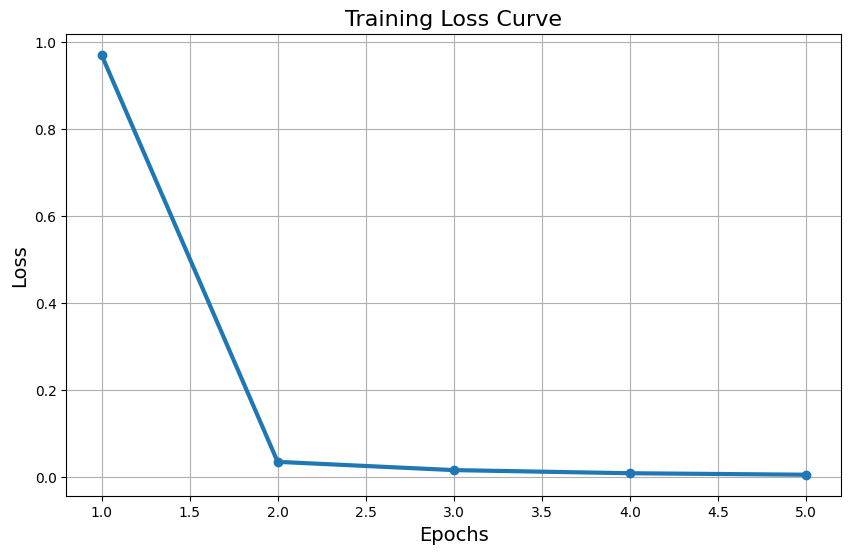

In [ ]:
epochs = [1, 2, 3, 4, 5]

plt.figure(figsize=(10,6))

plt.plot(
    epochs,
    losses,
    marker='o',
    linewidth=3
)

plt.xlabel(
    'Epochs',
    fontsize=14
)

plt.ylabel(
    'Loss',
    fontsize=14
)

plt.title(
    'Training Loss Curve',
    fontsize=16
)

plt.grid(True)

plt.savefig(
    'training_loss_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
from sklearn.metrics import precision_score

In [ ]:
precision = precision_score(
    y_true,
    y_pred,
    average='binary',
    zero_division=1
)

print("Precision:", precision)

Precision: 1.0


In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for x_batch, y_batch in loader:

        x_batch = x_batch.to(device)
        outputs = model(x_batch)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Prediction Completed")

Prediction Completed


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0,1]
)

print(cm)

[[2300    0]
 [   0    0]]


Confusion Matrix:
 [[2300    0]
 [   0    0]]


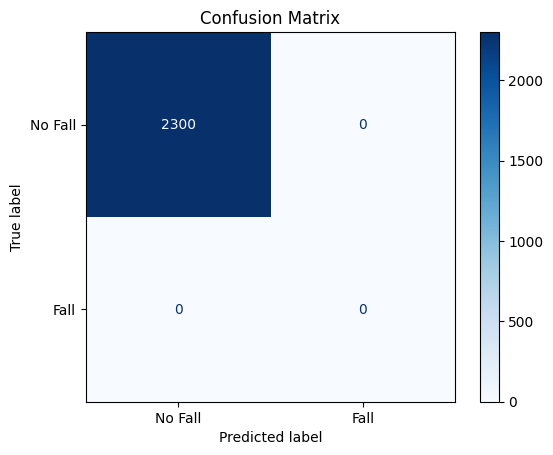

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# labels=[0,1] explicitly pass karo
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Fall", "Fall"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import torch
print("Unique labels:", torch.unique(labels))

Unique labels: tensor([0])


In [ ]:
import os

base_path = '/content/dataset/SisFall_dataset'

# Sirf ek subject folder ke andar jhaank ke dekhte hain
sample_folder = os.path.join(base_path, os.listdir(base_path)[0])
print("Folder:", sample_folder)
print("Files:", os.listdir(sample_folder)[:20])

Folder: /content/dataset/SisFall_dataset/SA18
Files: ['D11_SA18_R01.txt', 'F02_SA18_R01.txt', 'D04_SA18_R01.txt', 'D10_SA18_R01.txt', 'F07_SA18_R03.txt', 'F07_SA18_R01.txt', 'D14_SA18_R01.txt', 'F01_SA18_R02.txt', 'D12_SA18_R04.txt', 'F03_SA18_R02.txt', 'D15_SA18_R01.txt', 'F03_SA18_R04.txt', 'F14_SA18_R05.txt', 'F12_SA18_R01.txt', 'D11_SA18_R03.txt', 'D05_SA18_R03.txt', 'F08_SA18_R01.txt', 'F09_SA18_R03.txt', 'F15_SA18_R03.txt', 'F12_SA18_R04.txt']


In [ ]:
import os
from collections import Counter

base_path = '/content/dataset/SisFall_dataset'
prefix_counter = Counter()

for subject_folder in os.listdir(base_path):
    subject_path = os.path.join(base_path, subject_folder)
    if not os.path.isdir(subject_path):
        continue
    for file_name in os.listdir(subject_path):
        if file_name.endswith('.txt'):
            prefix_counter[file_name[:3]] += 1  # pehle 3 letters (jaise D01, F01)

print(prefix_counter)

Counter({'D11': 190, 'D14': 190, 'D12': 190, 'D15': 190, 'D05': 190, 'D07': 190, 'D08': 190, 'D16': 190, 'D17': 189, 'D10': 185, 'D09': 185, 'F02': 120, 'F07': 120, 'F03': 120, 'F14': 120, 'F12': 120, 'F08': 120, 'F09': 120, 'F15': 120, 'F04': 120, 'F13': 120, 'D18': 120, 'D13': 120, 'D19': 120, 'F06': 120, 'F11': 120, 'F05': 120, 'F01': 119, 'F10': 119, 'D06': 118, 'D03': 38, 'D02': 38, 'D01': 38, 'D04': 36})


In [ ]:
import os
import pandas as pd

base_path = '/content/dataset/SisFall_dataset'

fall_files_found = 0
fall_files_read_ok = 0
fall_files_failed = 0
errors = []

for subject_folder in os.listdir(base_path):
    subject_path = os.path.join(base_path, subject_folder)
    if not os.path.isdir(subject_path):
        continue
    for file_name in os.listdir(subject_path):
        if file_name.startswith('F') and file_name.endswith('.txt'):
            fall_files_found += 1
            file_path = os.path.join(subject_path, file_name)
            try:
                data = pd.read_csv(file_path, header=None, delimiter=',')
                fall_files_read_ok += 1
            except Exception as e:
                fall_files_failed += 1
                if len(errors) < 3:
                    errors.append((file_name, str(e)))

print("Total F files found:", fall_files_found)
print("Successfully read:", fall_files_read_ok)
print("Failed to read:", fall_files_failed)
print("Sample errors:", errors)

Total F files found: 1798
Successfully read: 1798
Failed to read: 0
Sample errors: []


In [ ]:
import os
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from collections import Counter

base_path = '/content/dataset/SisFall_dataset'
window_size = 100

all_sequences = []
all_labels = []

label_counter = Counter()
failed_files = []

for subject_folder in os.listdir(base_path):
    subject_path = os.path.join(base_path, subject_folder)
    if not os.path.isdir(subject_path):
        continue

    for file_name in os.listdir(subject_path):
        if not file_name.endswith('.txt'):
            continue

        if file_name.startswith('D'):
            label = 0
        elif file_name.startswith('F'):
            label = 1
        else:
            continue

        file_path = os.path.join(subject_path, file_name)

        try:
            data = pd.read_csv(file_path, header=None, delimiter=',')

            # Semicolon hatao aur sab numeric bana do
            data = data.replace(';', '', regex=True)
            data = data.apply(pd.to_numeric, errors='coerce')
            data = data.dropna()

            if data.empty:
                continue

        except Exception as e:
            failed_files.append((file_name, str(e)))
            continue

        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(data)
        tensor_data = torch.tensor(scaled_data, dtype=torch.float32)

        if len(tensor_data) <= window_size:
            continue

        for i in range(0, len(tensor_data) - window_size, window_size):
            seq = tensor_data[i:i + window_size]
            all_sequences.append(seq)
            all_labels.append(label)
            label_counter[label] += 1

sequences = torch.stack(all_sequences)
labels = torch.tensor(all_labels, dtype=torch.long)

print("Label counts:", label_counter)
print("Total sequences:", len(all_sequences))
print("Failed files:", len(failed_files))
print("Sample failed:", failed_files[:3])
print("sequences shape:", sequences.shape)
print("labels shape:", labels.shape)

Label counts: Counter({0: 101994, 1: 52143})
Total sequences: 154137
Failed files: 0
Sample failed: []
sequences shape: torch.Size([154137, 100, 9])
labels shape: torch.Size([154137])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(sequences, labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("DataLoader Ready with", len(dataset), "samples")

DataLoader Ready with 154137 samples


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer Ready")

Optimizer Ready


In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for x_batch, y_batch in loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 1035.4320
Epoch 2, Loss: 724.1812
Epoch 3, Loss: 593.1503
Epoch 4, Loss: 508.8022
Epoch 5, Loss: 446.2838


In [ ]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for x_batch, y_batch in loader:

        x_batch = x_batch.to(device)

        outputs = model(x_batch)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Predictions Generated Successfully")

Predictions Generated Successfully


Confusion Matrix:
 [[98505  3489]
 [ 2092 50051]]


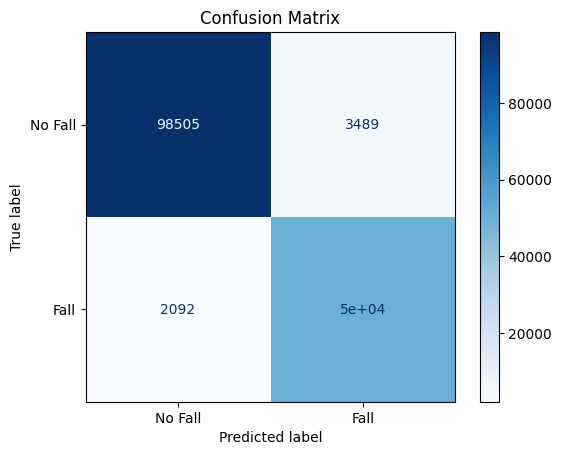

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Fall", "Fall"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["No Fall", "Fall"]))

              precision    recall  f1-score   support

     No Fall       0.98      0.97      0.97    101994
        Fall       0.93      0.96      0.95     52143

    accuracy                           0.96    154137
   macro avg       0.96      0.96      0.96    154137
weighted avg       0.96      0.96      0.96    154137



In [ ]:
torch.save(model.state_dict(), "cnn_transformer_model_fixed.pth")

from google.colab import files
files.download("cnn_transformer_model_fixed.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>